Ausreißer identifizieren und gegebenenfalls neuen dataframe ohne Ausreißer erstellen
- mit Gemini gemacht

In [16]:
import pm4py
import pandas as pd
import matplotlib.pyplot as plt

log = pm4py.read_xes('/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-03-19 BPI Challenge Dataset 2020/DomesticDeclarations.xes')

parsing log, completed traces :: 100%|██████████| 10500/10500 [00:00<00:00, 10832.02it/s]


In [17]:
# Durchlaufzeiten pro Fall berechnen
all_case_durations = pm4py.get_all_case_durations(log)

# Liste oder Dict
if isinstance(all_case_durations, list):
    # Wenn Liste, dann Index als Case-ID Ersatz
    df_durations = pd.DataFrame({
        'case_id': range(len(all_case_durations)),
        'duration_sec': all_case_durations
    })
else:
    # Wenn Dictionary
    df_durations = pd.DataFrame(list(all_case_durations.items()), columns=['case_id', 'duration_sec'])

# Umrechnung in Tage
df_durations['duration_days'] = df_durations['duration_sec'] / (24 * 3600)

In [18]:
# Ausreißer identifizieren (IQR Methode)
Q1 = df_durations['duration_days'].quantile(0.25)
Q3 = df_durations['duration_days'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Markierung setzen
df_durations['type'] = 'Normal'
df_durations.loc[df_durations['duration_days'] > upper_bound, 'type'] = 'Ausreißer (Lang)'
df_durations.loc[df_durations['duration_days'] < lower_bound, 'type'] = 'Ausreißer (Kurz)'

In [19]:
# Ergebnisse ausgeben
print(f"Statistik der Laufzeiten (Tage):\n{df_durations['duration_days'].describe()}\n")
print(f"Anzahl extrem langer Fälle: {len(df_durations[df_durations['type'] == 'Ausreißer (Lang)'])}")
print(f"Anzahl extrem kurzer Fälle: {len(df_durations[df_durations['type'] == 'Ausreißer (Kurz)'])}")

Statistik der Laufzeiten (Tage):
count    10500.000000
mean        11.525551
std         17.020116
min          0.000000
25%          5.817023
50%          7.330509
75%         12.241227
max        469.277986
Name: duration_days, dtype: float64

Anzahl extrem langer Fälle: 891
Anzahl extrem kurzer Fälle: 0


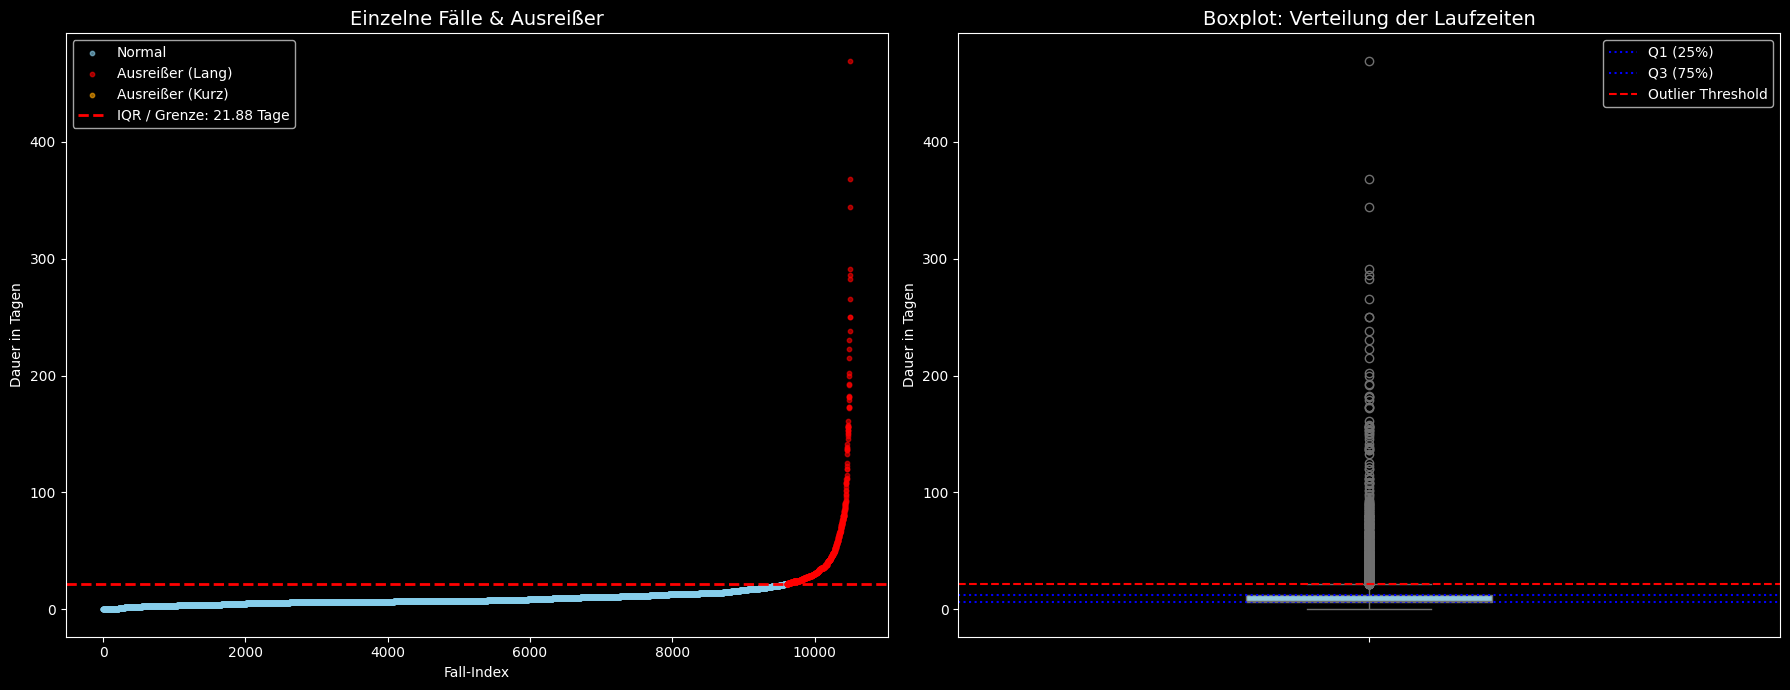

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vorbereitung Leinwand
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Scatter Plot
colors = {'Normal': 'skyblue', 'Ausreißer (Lang)': 'red', 'Ausreißer (Kurz)': 'orange'}
for label, color in colors.items():
    subset = df_durations[df_durations['type'] == label]
    ax1.scatter(subset.index, subset['duration_days'], c=color, label=label, alpha=0.6, s=10)

#ax1.axhline(upper_bound, color='red', linestyle='--', label='Obere Grenze (1.5*IQR)')
ax1.axhline(upper_bound, color='red', linestyle='--', linewidth=2, label=f'IQR / Grenze: {upper_bound:.2f} Tage')
ax1.set_title('Einzelne Fälle & Ausreißer', fontsize=14)
ax1.set_ylabel('Dauer in Tagen')
ax1.set_xlabel('Fall-Index')
ax1.legend()

# Plot 2: Boxplot
sns.boxplot(y=df_durations['duration_days'], ax=ax2, color='skyblue', width=0.3)

ax2.axhline(Q1, color='blue', linestyle=':', label='Q1 (25%)')
ax2.axhline(Q3, color='blue', linestyle=':', label='Q3 (75%)')
ax2.axhline(upper_bound, color='red', linestyle='--', label='Outlier Threshold')

ax2.set_title('Boxplot: Verteilung der Laufzeiten', fontsize=14)
ax2.set_ylabel('Dauer in Tagen')
ax2.legend()

plt.tight_layout()
plt.show()

In [36]:
import pandas as pd
import numpy as np

# Jedem Case eine eindeutige Nummer geben (Proxy-ID)
# Mapping erstellen: Case-Name -> Nummer
unique_cases = log['case:concept:name'].unique()
case_to_num = {name: i for i, name in enumerate(unique_cases)}

# Neue Spalte 'temp_id' im Log und im Statistik-DF hinzufügen
log['temp_id'] = log['case:concept:name'].map(case_to_num)

# Durchlaufzeiten basierend auf neuer temp_id berechnen
durations = log.groupby('temp_id')['time:timestamp'].agg(lambda x: (x.max() - x.min()).total_seconds())
df_stats = pd.DataFrame({'temp_id': durations.index, 'duration_days': durations.values / (24 * 3600)})

# Ausreißer-Grenze berechnen
Q3 = df_stats['duration_days'].quantile(0.75)
IQR = Q3 - df_stats['duration_days'].quantile(0.25)
upper_bound = Q3 + 1.5 * IQR

# Nur die IDs der "zu langen" Fälle finden
long_outlier_ids = df_stats[df_stats['duration_days'] > upper_bound]['temp_id'].tolist()

# Filtern: Zeilen behalten, deren temp_id nicht in der Liste ist
log_cleaned = log[~log['temp_id'].isin(long_outlier_ids)].copy()

# Hilfsspalte wieder löschen
log_cleaned.drop(columns=['temp_id'], inplace=True)
log.drop(columns=['temp_id'], inplace=True) # auch im Original löschen

# Check
print(f"Ursprüngliche Fälle: {len(unique_cases)}")
print(f"Entfernte lange Fälle: {len(long_outlier_ids)}")
print(f"Verbleibende Fälle: {log_cleaned['case:concept:name'].nunique()}")

Ursprüngliche Fälle: 10500
Entfernte lange Fälle: 891
Verbleibende Fälle: 9609
